In [2]:
import numpy as np
import pandas as pd

df_raw = pd.read_csv(
    "dataset_updated.csv",
    sep=";",
    header=1,
    decimal=",",
    encoding="utf-8-sig",
)

# Очистка колонок и структуры от мусора
df_raw.columns = df_raw.columns.str.strip()
df_raw = df_raw.dropna(subset=["country"])
df_raw = df_raw[df_raw["country"].str.strip() != ""]
df_raw = df_raw[df_raw["country"].str.lower() != "country"]

df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce")
df_raw = df_raw.dropna(subset=["year"])
df_raw["year"] = df_raw["year"].astype(int)

# Список целевых признаков
target_features = [
    "country",
    "year",
    # Демография
    "tfr",
    "dep_young",
    "dep_old",
    "depopulation_rate",
    # Здравоохранение
    "infant_mortality",
    "life_expectancy",
    "health_exp_pc",
    "abortions",
    # Экономика и жилье
    "gdp_percapita",
    "gni_percapita",
    "apartments_built",
    "Unemployment",
    # Социум и институты
    "marriage_vitality",
    "marriages",
    "migration",
    "high_educ",
]

df_target = df_raw[target_features].copy()
num_cols = [c for c in target_features if c not in ["country", "year"]]

# Очистка числовых колонок от текстовых аномалий и спецсимволов
for col in num_cols:
    df_target[col] = (
        df_target[col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace("\xa0", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace("#ДЕЛ/0!", np.nan)
    )
    df_target[col] = pd.to_numeric(df_target[col], errors="coerce")

print(f"Целевой датасет сформирован: {df_target.shape[0]} строк, {df_target.shape[1]} колонок")
print(f"Пропусков до обработки: {df_target[num_cols].isna().sum().sum()}")


# Восстановление пропусков: линейная внутристрановая интерполяция с процедурой LOCF/NOCB
def smart_impute_country(group):
    group = group.sort_values(by="year")

    # Строго внутристрановая интерполяция (без вывешивания искусственных трендов наружу)
    group[num_cols] = group[num_cols].interpolate(
        method="linear", limit_area="inside"
    )

    # Реальный LOCF (вперед) и NOCB (назад) для краев ряда
    group[num_cols] = group[num_cols].ffill().bfill()

    return group


# Применяем групповое восстановление
df_model_ready = (
    df_target.groupby("country", group_keys=False)
    .apply(smart_impute_country)
    .reset_index(drop=True)
)


# Удаление Туркменистана из анализа
df_model_ready = df_model_ready[df_model_ready["country"] != "Туркменистан"].reset_index(drop=True)

print(f"Пропусков после внутристрановой обработки: {df_model_ready[num_cols].isna().sum().sum()}")


# Индекс смены поколений (дети к старикам)
df_model_ready["generation_ratio"] = (
    df_model_ready["dep_young"] / df_model_ready["dep_old"]
)

# Обеспеченность новых браков жильем (квартир на 1 брак) с защитой от деления на 0
df_model_ready["homes_per_marriage"] = (
    df_model_ready["apartments_built"]
    / df_model_ready["marriages"].replace(0, np.nan)
)

print(f"Итоговый массив сформирован: {df_model_ready.shape[1]} колонок.")
display(df_model_ready.head(10))

# df_model_ready.to_csv("dataset_for_models.csv", index=False, encoding="utf-8-sig")
# df_model_ready.to_excel("dataset_for_models.xlsx", index=False)

Целевой датасет сформирован: 340 строк, 18 колонок
Пропусков до обработки: 1081
Пропусков после внутристрановой обработки: 0
Итоговый чистый массив сформирован: 20 колонок.


C:\Users\arina\AppData\Local\Temp\ipykernel_2668\2326052117.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(smart_impute_country)


,country,year,tfr,dep_young,dep_old,depopulation_rate,infant_mortality,life_expectancy,health_exp_pc,abortions,gdp_percapita,gni_percapita,apartments_built,Unemployment,marriage_vitality,marriages,migration,high_educ,generation_ratio,homes_per_marriage
0,Азербайджан,1991,2.0,47.332684,8.274349,0.233083,25.3,66.3,25.660637,4.1,5412.097602,160.0,40.0,14.9,6.933333,10.4,-40.1,150.0,5.720412,3.846154
1,Азербайджан,1992,2.0,48.945994,9.091162,0.284000,25.5,65.4,25.660637,4.1,4220.146373,160.0,33.0,14.9,7.307692,9.5,-14.2,136.0,5.383909,3.473684
2,Азербайджан,1993,2.0,51.227522,10.256699,0.303797,28.2,65.2,25.660637,4.1,3272.237950,110.0,23.0,14.9,9.000000,8.1,-12.2,127.0,4.994543,2.839506
3,Азербайджан,1994,2.0,52.380366,11.357734,0.341121,25.2,65.2,25.660637,4.1,2647.765384,80.0,12.0,14.9,7.875000,6.3,-11.0,119.0,4.611868,1.904762
4,Азербайджан,1995,2.0,52.413439,12.280731,0.354497,23.3,65.2,25.660637,4.1,2356.897801,180.0,9.0,14.9,7.125000,5.7,-9.8,130.0,4.267941,1.578947
5,Азербайджан,1996,2.0,51.589722,12.972943,0.372781,19.9,66.3,25.660637,4.1,2406.772316,240.0,7.0,14.9,7.285714,5.1,-7.4,134.0,3.976717,1.372549
6,Азербайджан,1997,2.0,50.524066,13.588266,0.356725,19.6,67.4,25.660637,4.1,2565.408282,410.0,7.0,14.9,7.625000,6.1,-8.2,129.0,3.718213,1.147541
7,Азербайджан,1998,2.0,47.924375,13.918630,0.371069,16.6,67.9,25.660637,4.1,2826.706934,510.0,7.0,14.9,7.428571,5.2,-5.1,136.0,3.443182,1.346154
8,Азербайджан,1999,2.0,44.112153,13.991642,0.395973,16.5,68.1,25.660637,4.1,3051.942333,600.0,5.0,14.9,8.000000,4.8,-4.3,147.0,3.152750,1.041667
9,Азербайджан,2000,2.0,40.653234,14.160155,0.401361,16.4,68.6,25.660637,4.1,3439.144429,630.0,7.0,14.9,7.142857,5.0,-5.5,150.0,2.870960,1.400000


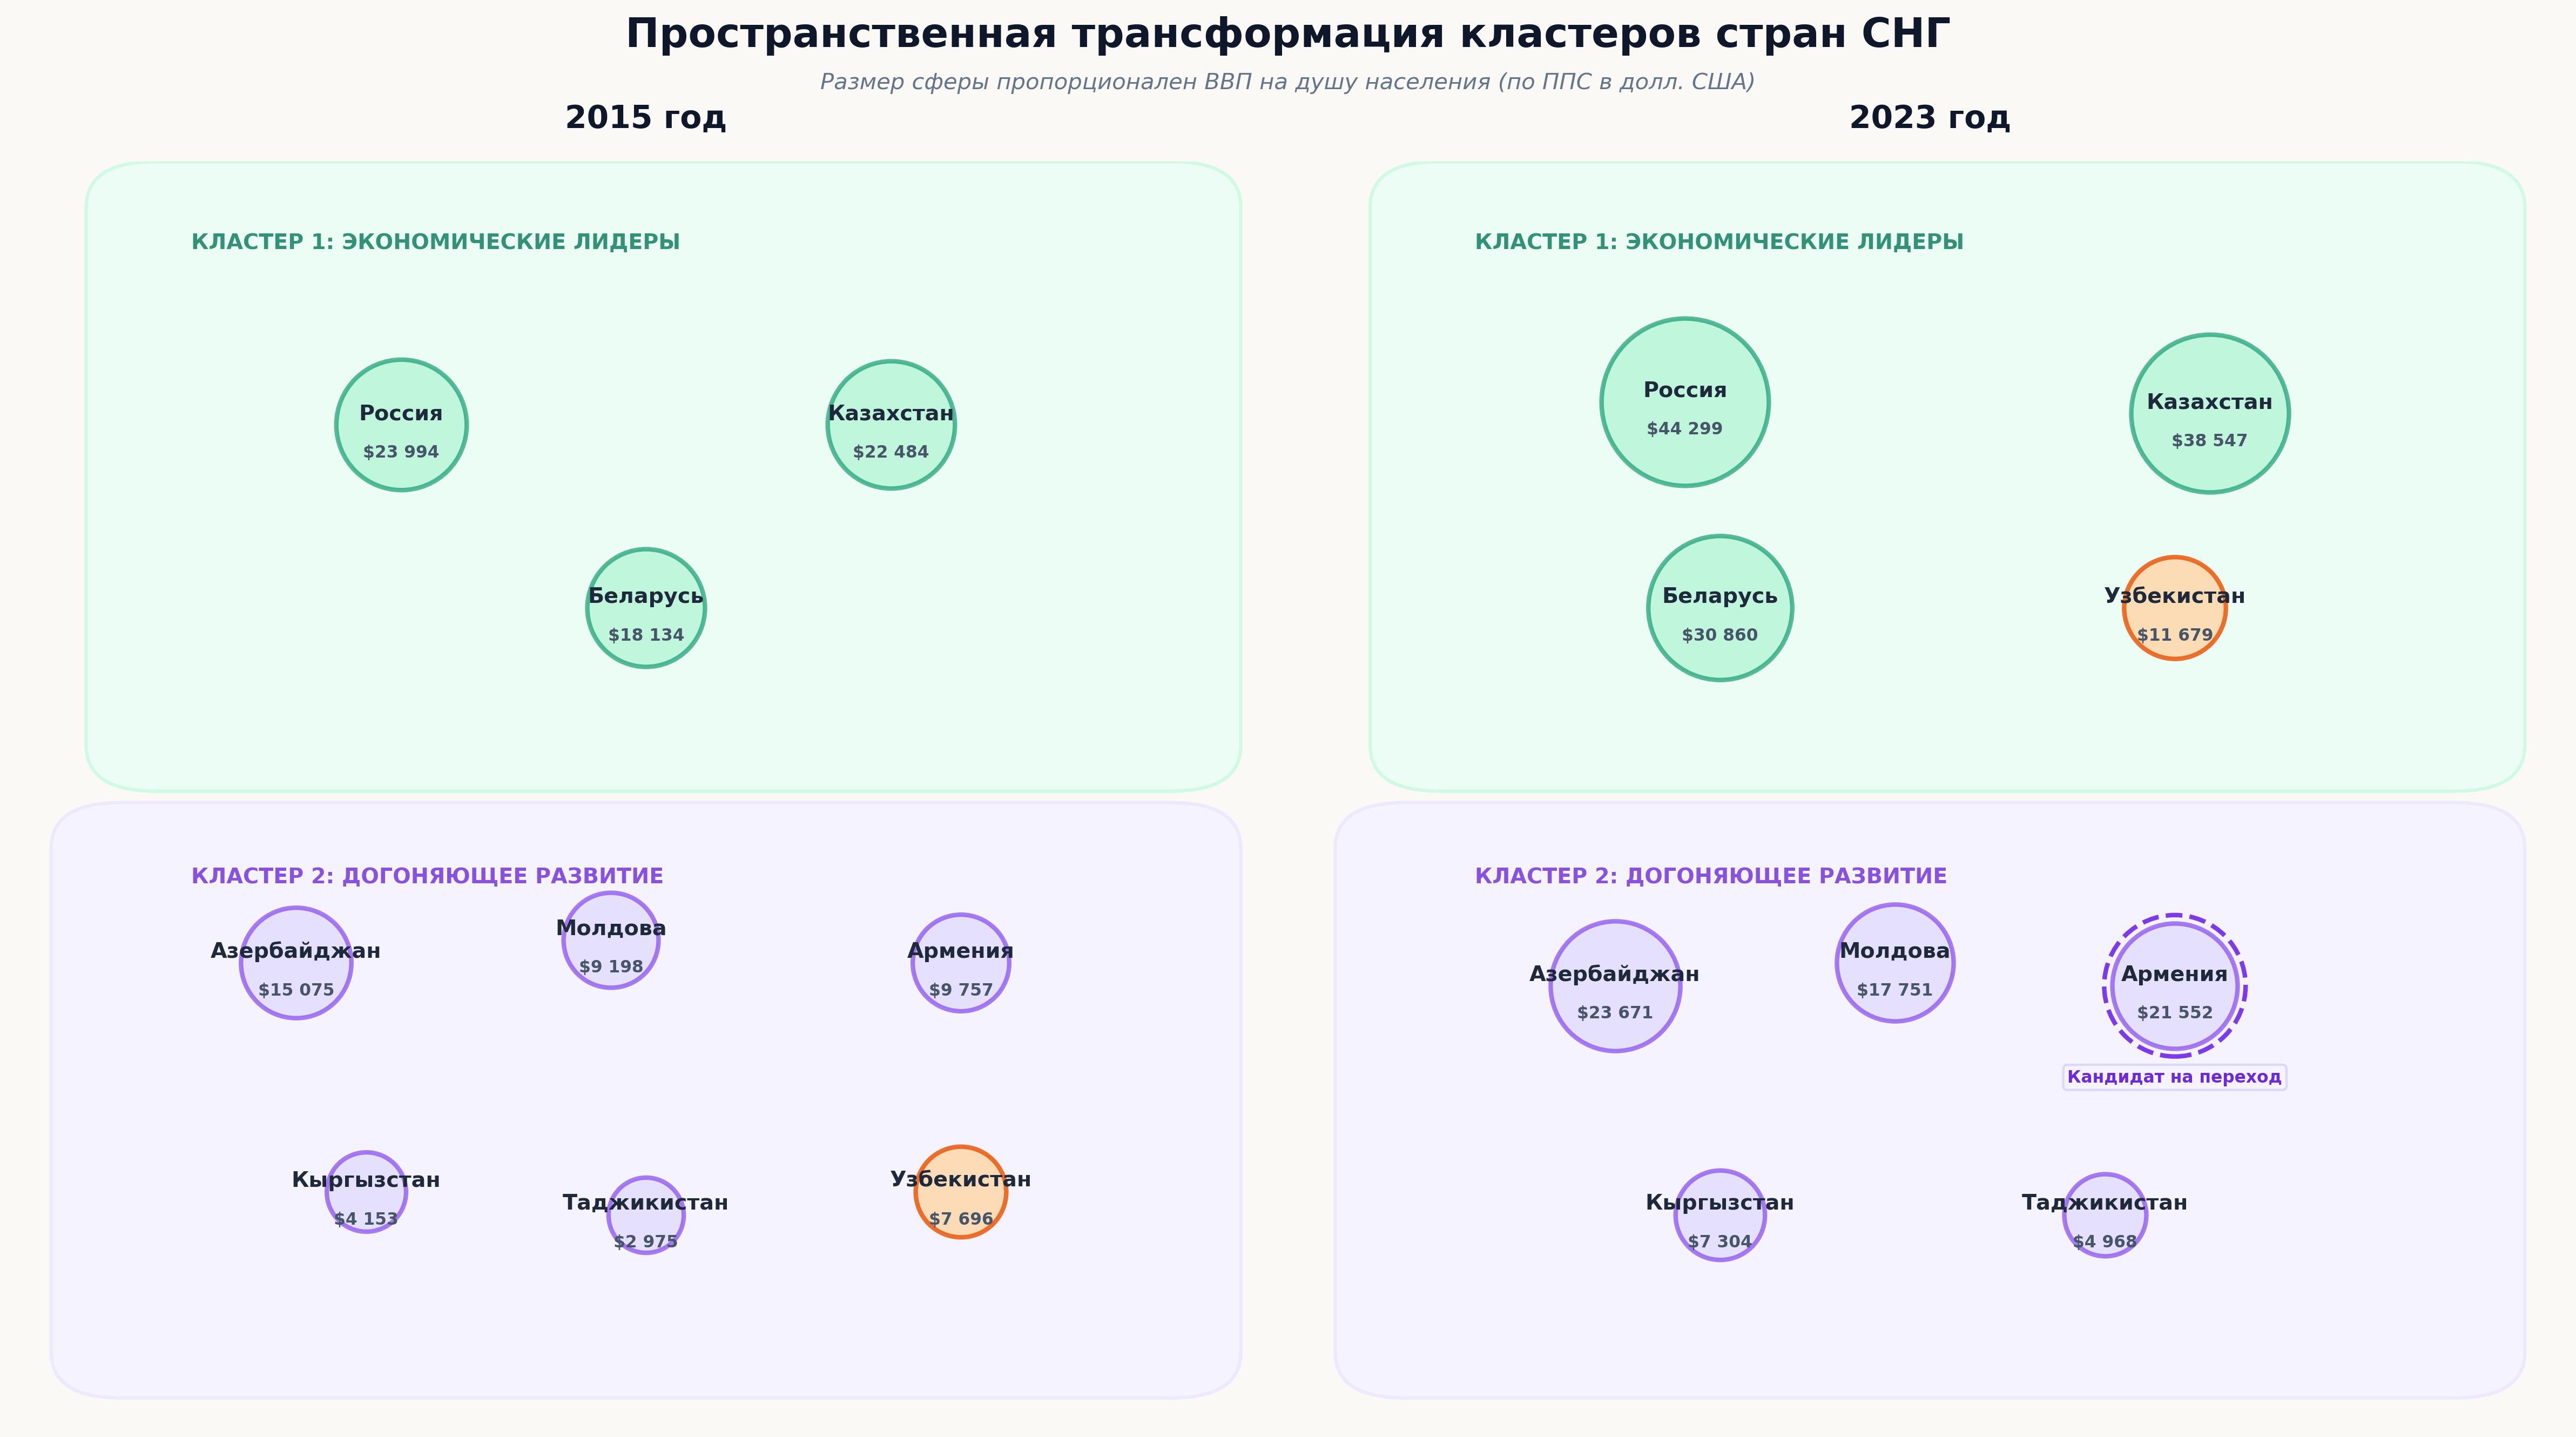

In [12]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# Данные по ВВП на душу (ППС, долл. США)
gdp_2015 = {
    "Россия": 23994,
    "Казахстан": 22484,
    "Беларусь": 18134,
    "Азербайджан": 15075,
    "Молдова": 9198,
    "Армения": 9757,
    "Узбекистан": 7696,
    "Кыргызстан": 4153,
    "Таджикистан": 2975,
}

gdp_2023 = {
    "Россия": 44299,
    "Казахстан": 38547,
    "Беларусь": 30860,
    "Азербайджан": 23671,
    "Армения": 21552,
    "Молдова": 17751,
    "Узбекистан": 11679,
    "Кыргызстан": 7304,
    "Таджикистан": 4968,
}

pos_15 = {
    # Кластер 1 
    "Россия": (-0.7, 1.65),
    "Казахстан": (0.7, 1.65),
    "Беларусь": (0.0, 0.85),
    # Кластер 2
    "Азербайджан": (-1.0, -0.7),
    "Молдова": (-0.1, -0.6),
    "Армения": (0.9, -0.7),
    "Кыргызстан": (-0.8, -1.7),
    "Таджикистан": (0.0, -1.8),
    "Узбекистан": (0.9, -1.7),
}

pos_23 = {
    # Кластер 1
    "Россия": (-0.7, 1.75),
    "Казахстан": (0.8, 1.7),
    "Беларусь": (-0.6, 0.85),
    "Узбекистан": (0.7, 0.85),
    # Кластер 2
    "Азербайджан": (-0.9, -0.8),
    "Молдова": (-0.1, -0.7),
    "Армения": (0.7, -0.8),
    "Кыргызстан": (-0.6, -1.8),
    "Таджикистан": (0.5, -1.8),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), dpi=300)
fig.patch.set_facecolor("#FAF9F6")

COLOR_C1, BORDER_C1 = "#A7F3D0", "#059669"  
COLOR_C2, BORDER_C2 = "#DDD6FE", "#7C3AED"  
COLOR_UZB, BORDER_UZB = "#FED7AA", "#EA580C"  


def draw_infographic(ax, pos, gdp_dict, year, is_2023=False):
    ax.set_facecolor("#FAF9F6")


    cloud1 = patches.FancyBboxPatch(
        (-1.4, 0.25),
        2.9,
        2.35,
        boxstyle="round,pad=0.2",
        fc="#ECFDF5",
        ec="#D1FAE5",
        lw=1.5,
        zorder=1,
    )
    cloud2 = patches.FancyBboxPatch(
        (-1.5, -2.4),
        3.0,
        2.2,
        boxstyle="round,pad=0.2",
        fc="#F5F3FF",
        ec="#EDE9FE",
        lw=1.5,
        zorder=1,
    )

    ax.add_patch(cloud1)
    ax.add_patch(cloud2)


    ax.text(
        -1.3,
        2.42,
        "КЛАСТЕР 1: ЭКОНОМИЧЕСКИЕ ЛИДЕРЫ",
        fontsize=9.5,
        fontweight="bold",
        color="#047857",
        alpha=0.8,
    )
    ax.text(
        -1.3,
        -0.35,
        "КЛАСТЕР 2: ДОГОНЯЮЩЕЕ РАЗВИТИЕ",
        fontsize=9.5,
        fontweight="bold",
        color="#6D28D9",
        alpha=0.8,
    )


    for country, (x, y) in pos.items():
        gdp = gdp_dict[country]
        size = (gdp / 45000) * 4800 + 800

        if country == "Узбекистан":
            bg_c, brd_c = COLOR_UZB, BORDER_UZB
            alpha = 0.85
        elif country in ["Беларусь", "Казахстан", "Россия"]:
            bg_c, brd_c = COLOR_C1, BORDER_C1
            alpha = 0.65
        else:
            bg_c, brd_c = COLOR_C2, BORDER_C2
            alpha = 0.65

        ax.scatter(
            x,
            y,
            s=size,
            facecolor=bg_c,
            edgecolor=brd_c,
            linewidth=2,
            alpha=alpha,
            zorder=3,
        )


        if is_2023 and country == "Армения":
            ax.scatter(
                x,
                y,
                s=size + 850,
                facecolor="none",
                edgecolor="#7C3AED",
                linewidth=2,
                linestyle="--",
                zorder=3,
            )


        ax.text(
            x,
            y + 0.05,
            country,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="#1E293B",
            zorder=4,
        )
        ax.text(
            x,
            y - 0.12,
            f"${gdp:,.0f}".replace(",", " "),
            ha="center",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color="#475569",
            zorder=4,
        )


    if is_2023:
        arm_x, arm_y = pos["Армения"]
        ax.text(
            arm_x,
            arm_y - 0.42,
            "Кандидат на переход",
            fontsize=7.5,
            fontweight="bold",
            color="#6D28D9",
            ha="center",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="#F5F3FF",
                ec="#DDD6FE",
                lw=1,
            ),
            zorder=6,
        )

    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-2.7, 2.8)
    ax.axis("off")



draw_infographic(ax1, pos_15, gdp_2015, 2015, is_2023=False)
ax1.set_title(
    "2015 год",
    fontsize=14,
    fontweight="bold",
    pad=15,
    color="#0F172A",
)

draw_infographic(ax2, pos_23, gdp_2023, 2023, is_2023=True)
ax2.set_title(
    "2023 год",
    fontsize=14,
    fontweight="bold",
    pad=15,
    color="#0F172A",
)

fig.suptitle(
    "Пространственная трансформация кластеров стран СНГ",
    fontsize=18,
    fontweight="bold",
    color="#0F172A",
    y=0.98,
)
plt.figtext(
    0.5,
    0.93,
    "Размер сферы пропорционален ВВП на душу населения (по ППС в долл. США)",
    ha="center",
    fontsize=10,
    color="#64748B",
    style="italic",
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("cis_aesthetic_infographic.png", dpi=300, facecolor=fig.get_facecolor())
plt.show()

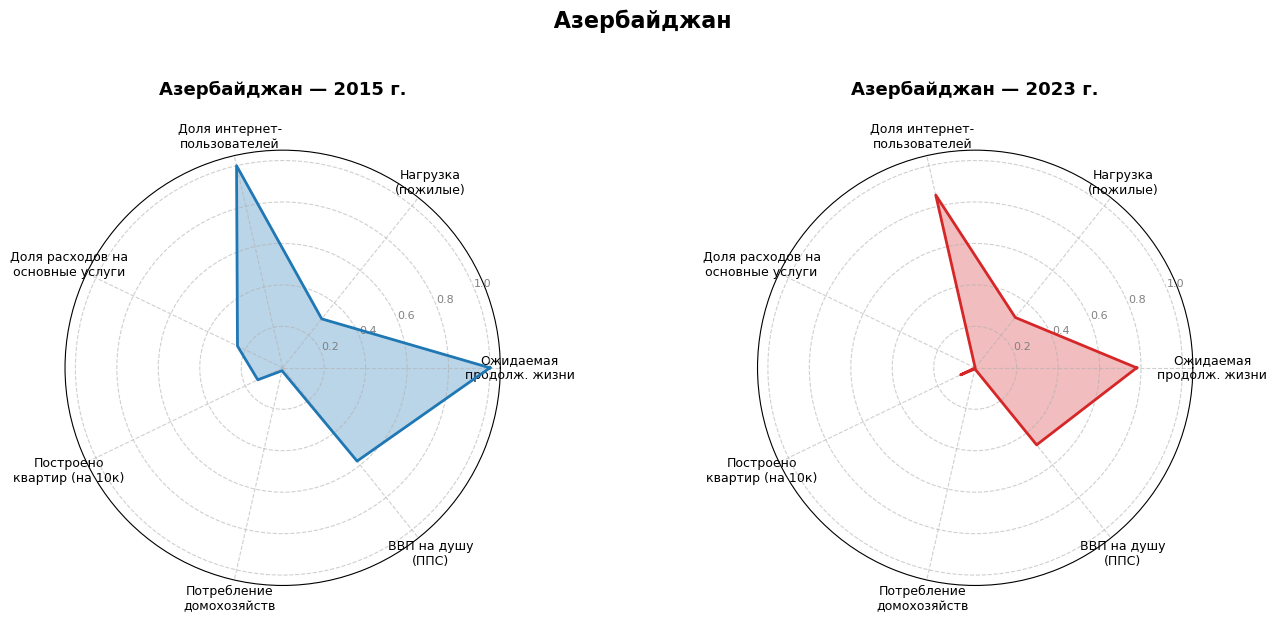

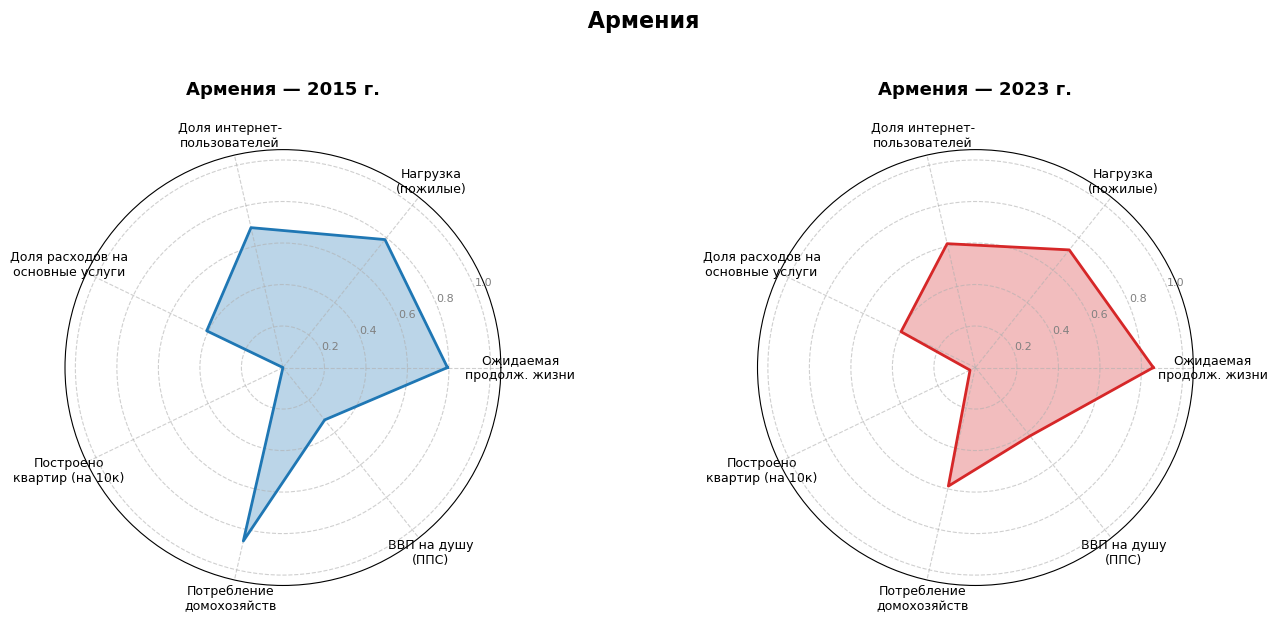

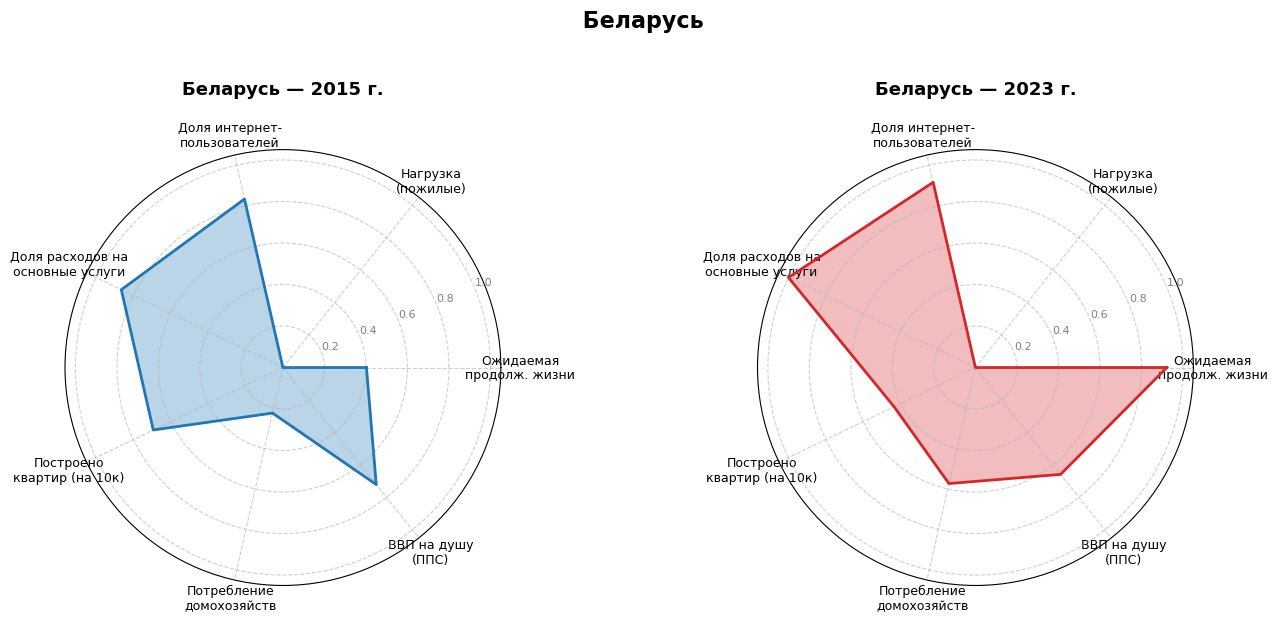

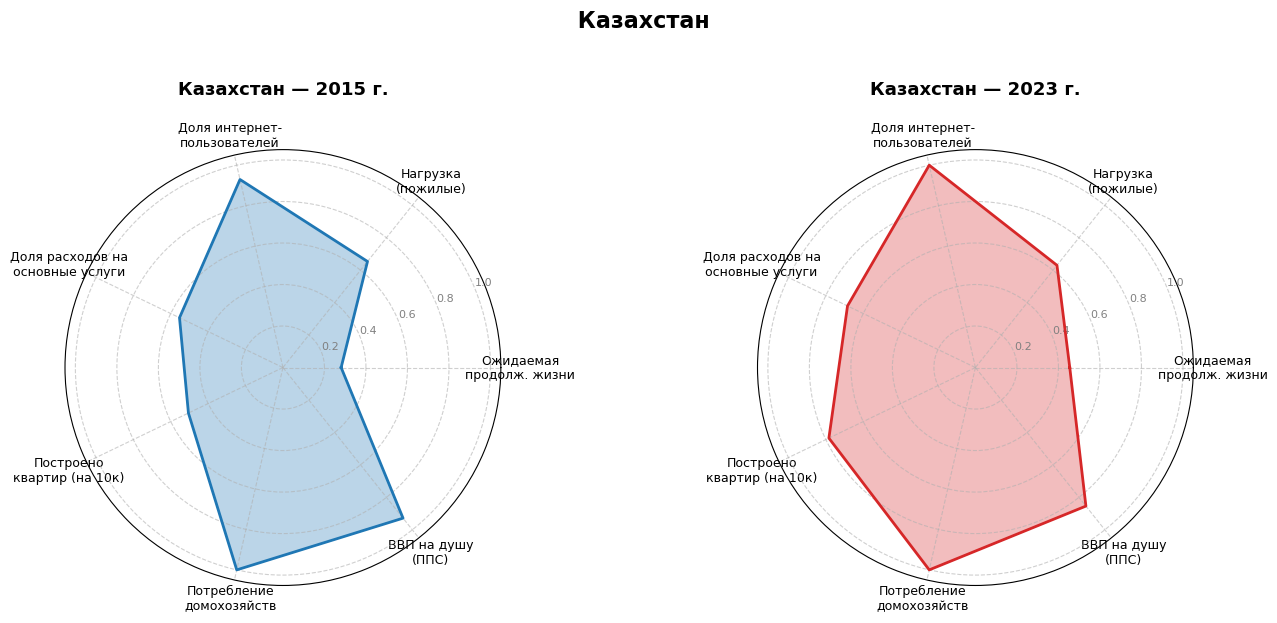

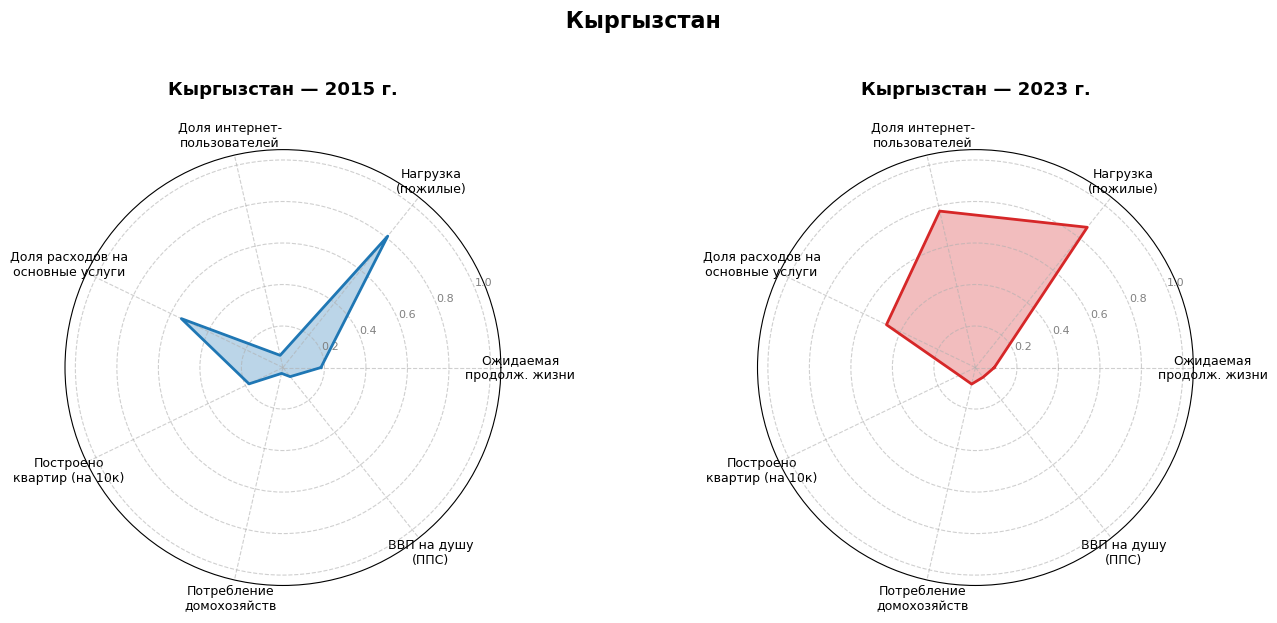

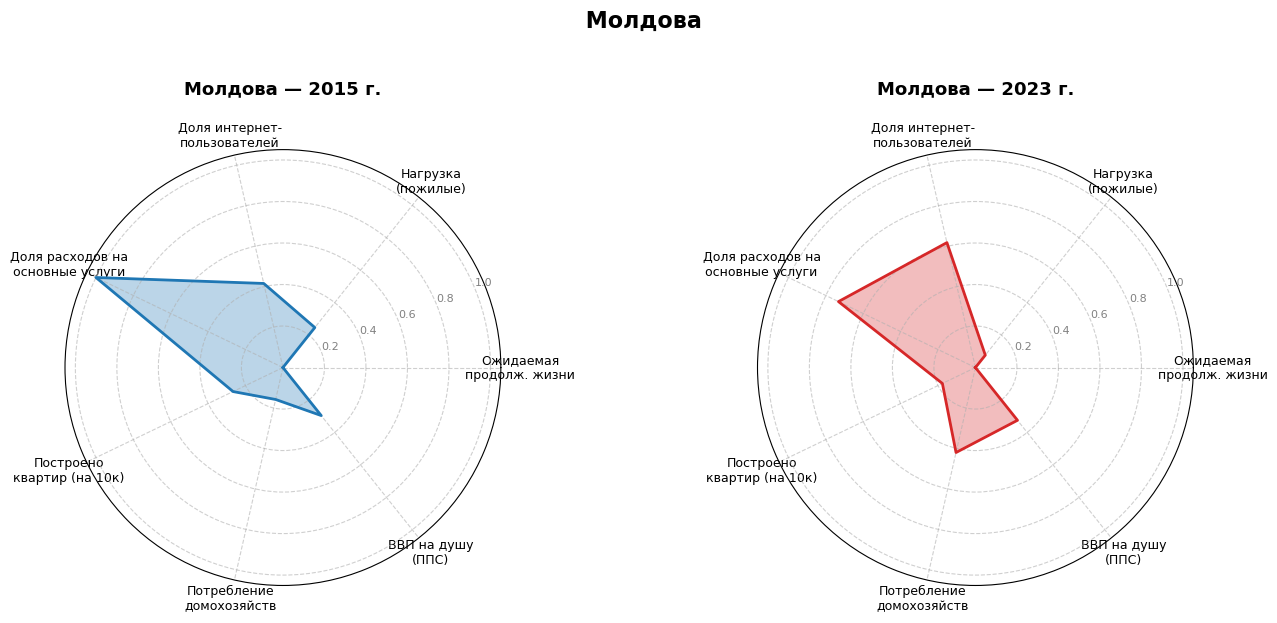

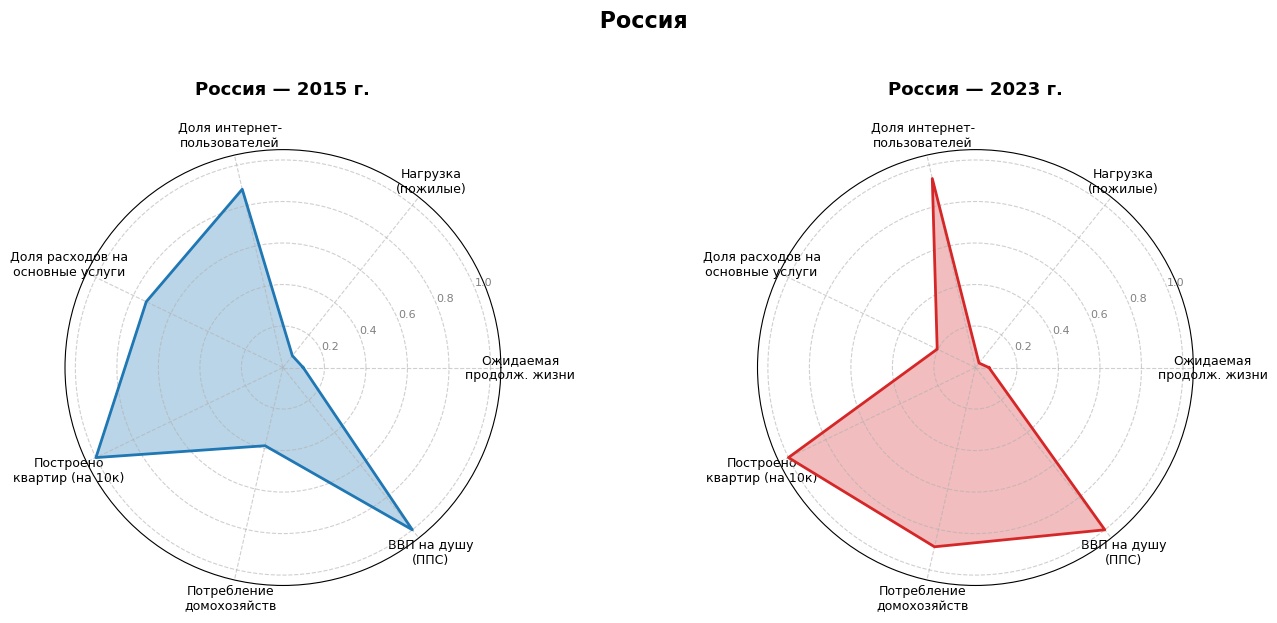

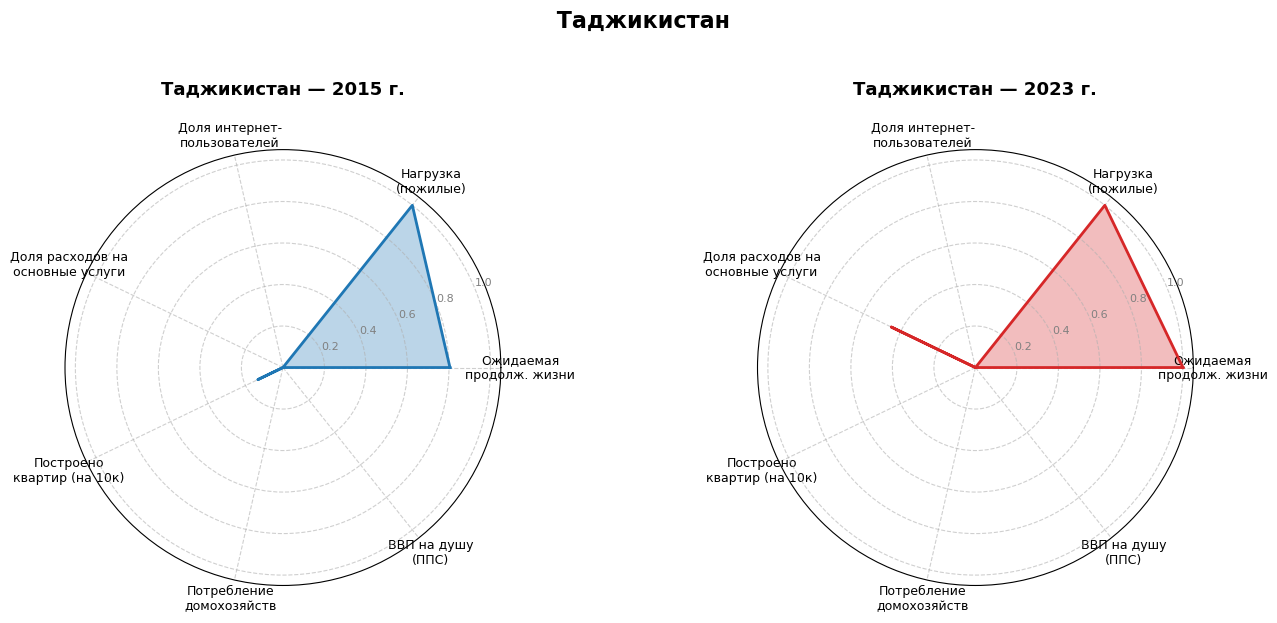

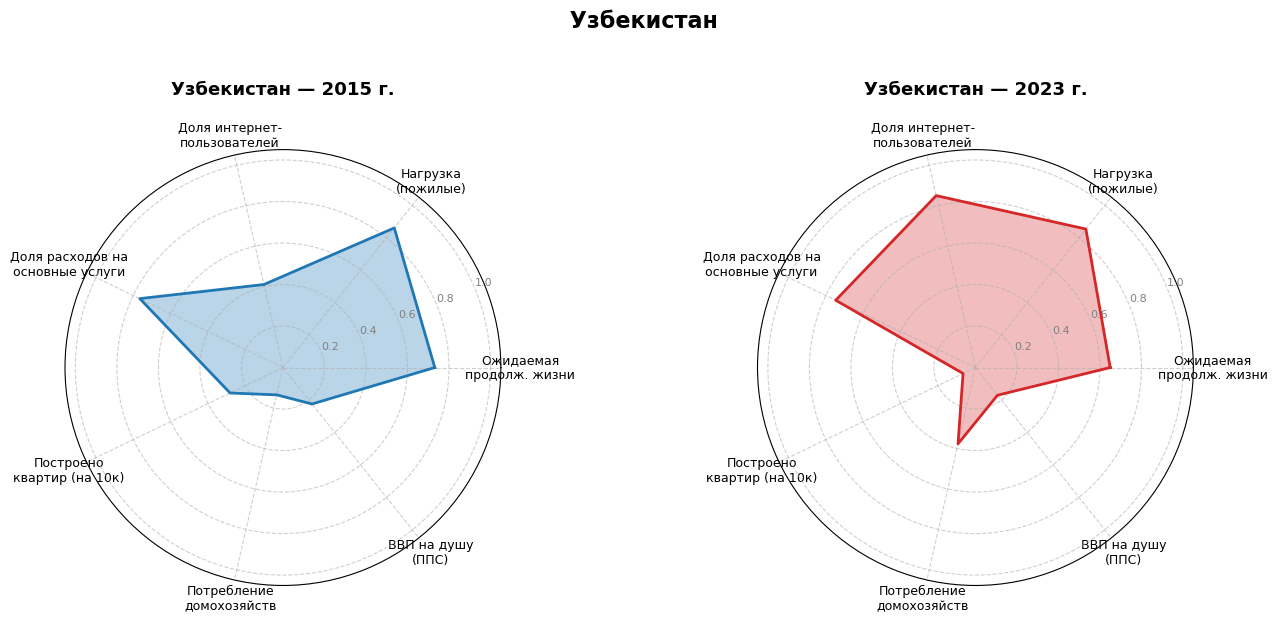

In [9]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_2015 = pd.read_csv("2015.csv", sep=";", decimal=",", encoding="utf-8-sig")
df_2023 = pd.read_csv("2023.csv", sep=";", decimal=",", encoding="utf-8-sig")

df_2015 = df_2015.set_index("Страна")
df_2023 = df_2023.set_index("Страна")

feature_labels = [
    "Ожидаемая\nпродолж. жизни",
    "Нагрузка\n(пожилые)",
    "Доля интернет-\nпользователей",
    "Доля расходов на\nосновные услуги",
    "Построено\nквартир (на 10к)",
    "Потребление\nдомохозяйств",
    "ВВП на душу\n(ППС)",
]

num_vars = len(feature_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


def draw_radar(ax, values, title, color):

    val_closed = values + values[:1]
    
    ax.plot(angles, val_closed, color=color, linewidth=2, linestyle="solid")
    ax.fill(angles, val_closed, color=color, alpha=0.3)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, fontsize=9)

    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ["0.2", "0.4", "0.6", "0.8", "1.0"], color="gray", size=8
    )

    ax.set_title(title, size=13, weight="bold", pad=20)
    ax.grid(True, linestyle="--", alpha=0.6)


countries = df_2015.index.intersection(df_2023.index)

for country in countries:
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 6), subplot_kw=dict(polar=True)
    )

    vals_2015 = df_2015.loc[country].values.astype(float).tolist()
    vals_2023 = df_2023.loc[country].values.astype(float).tolist()

    draw_radar(
        ax1, vals_2015, title=f"{country} — 2015 г.", color="#1f77b4"
    )  
    draw_radar(
        ax2, vals_2023, title=f"{country} — 2023 г.", color="#d62728"
    )  

    plt.suptitle(
        f" {country}", fontsize=16, weight="bold", y=1.03
    )
    plt.tight_layout()
    plt.show()

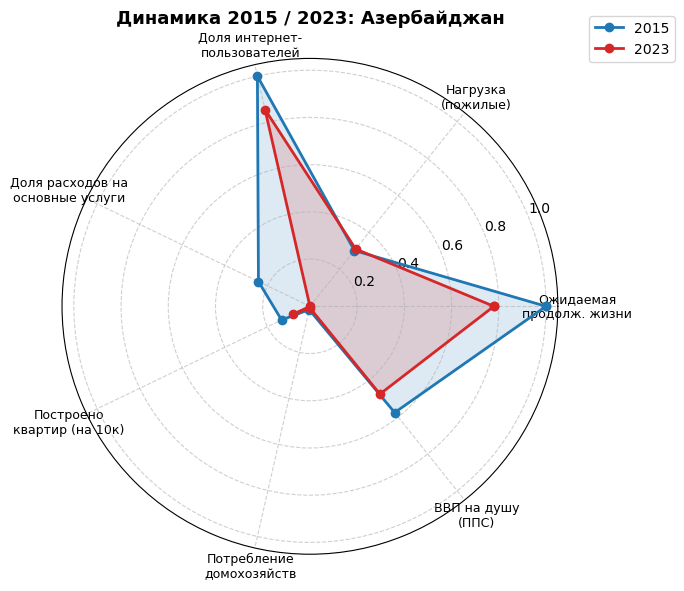

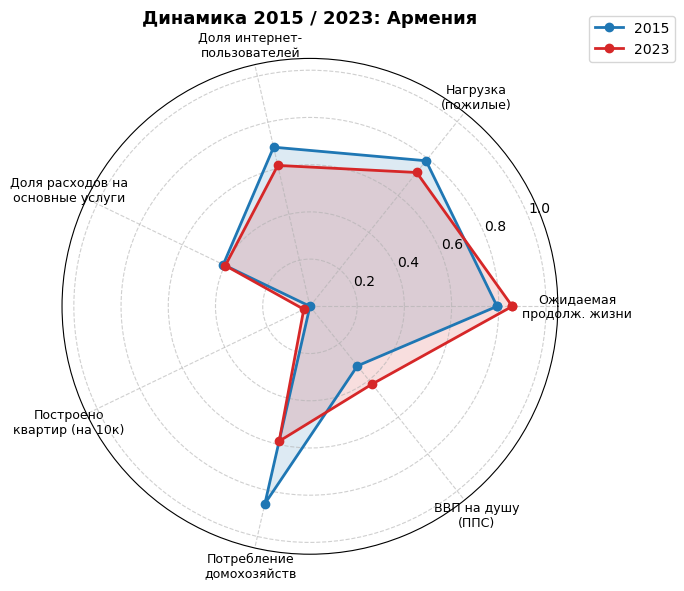

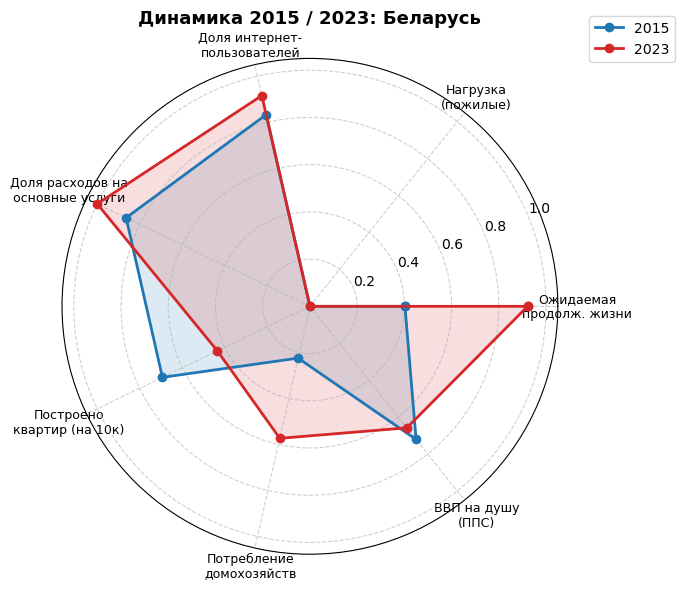

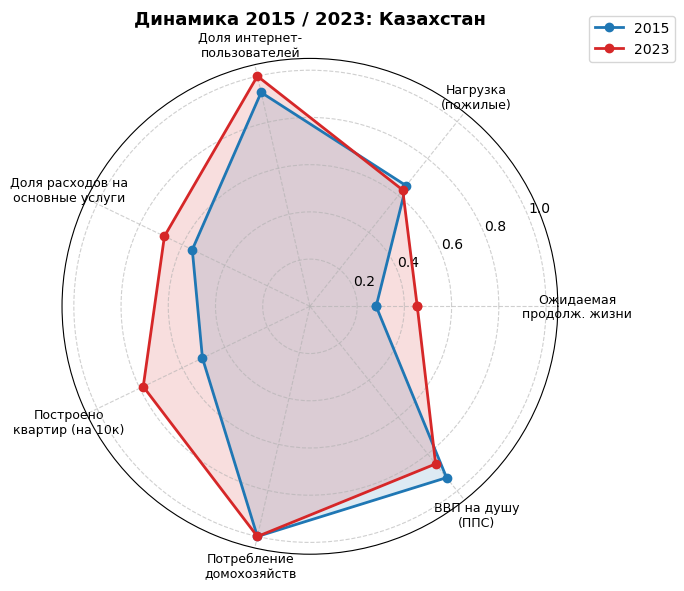

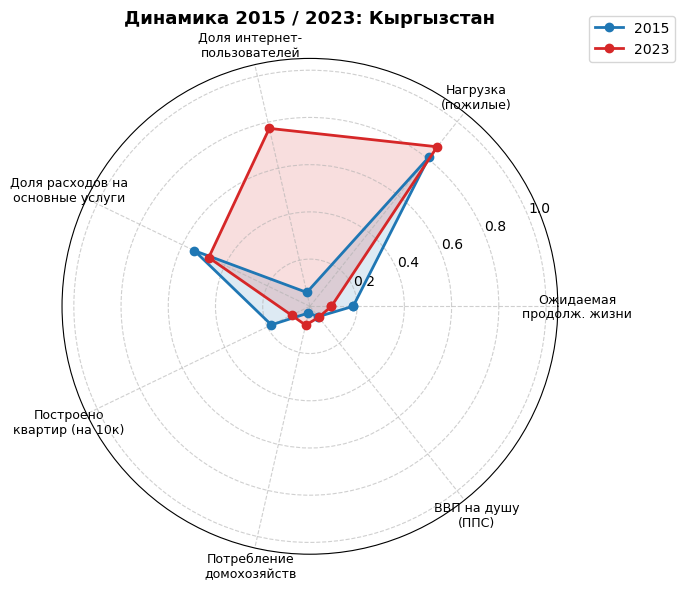

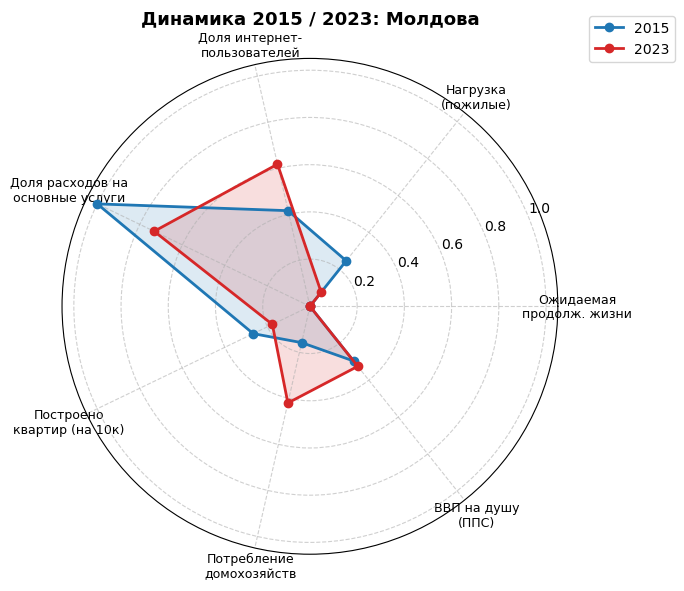

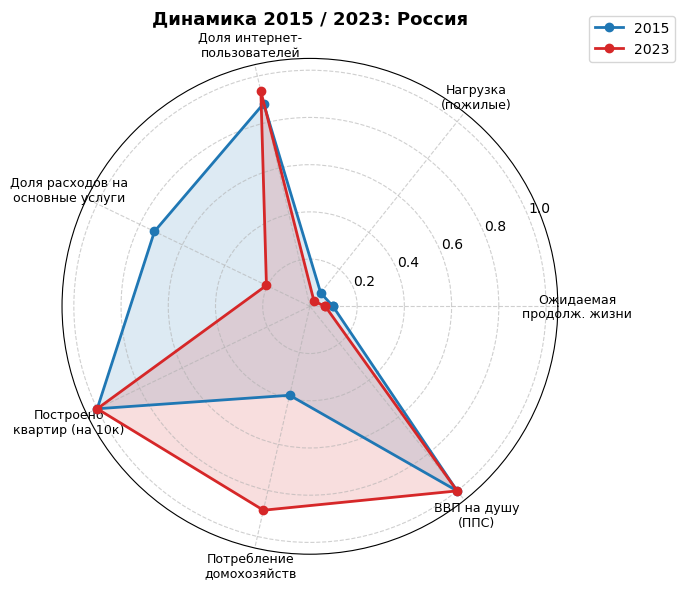

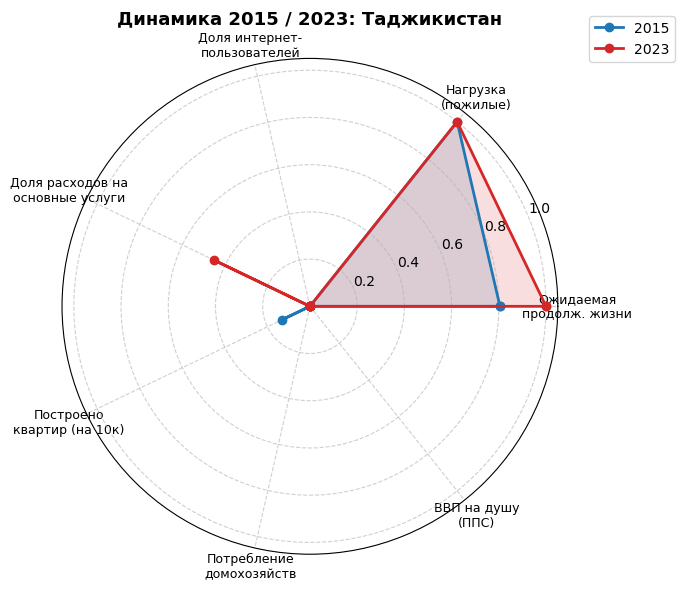

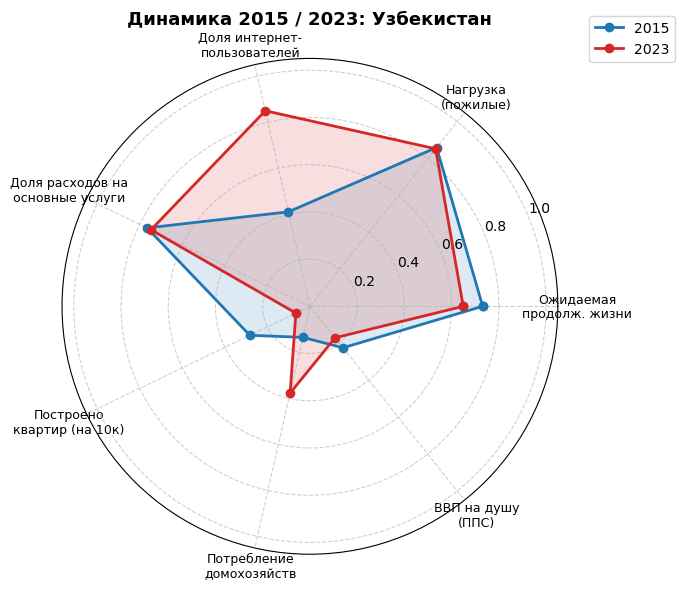

In [10]:
for country in countries:
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    vals_15 = df_2015.loc[country].values.astype(float).tolist() + [
        df_2015.loc[country].values[0]
    ]
    vals_23 = df_2023.loc[country].values.astype(float).tolist() + [
        df_2023.loc[country].values[0]
    ]

    ax.plot(
        angles, vals_15, color="#1f77b4", linewidth=2, label="2015", marker="o"
    )
    ax.fill(angles, vals_15, color="#1f77b4", alpha=0.15)

    ax.plot(
        angles, vals_23, color="#d62728", linewidth=2, label="2023", marker="o"
    )
    ax.fill(angles, vals_23, color="#d62728", alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"Динамика 2015 / 2023: {country}", size=13, weight="bold", pad=25
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
    ax.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

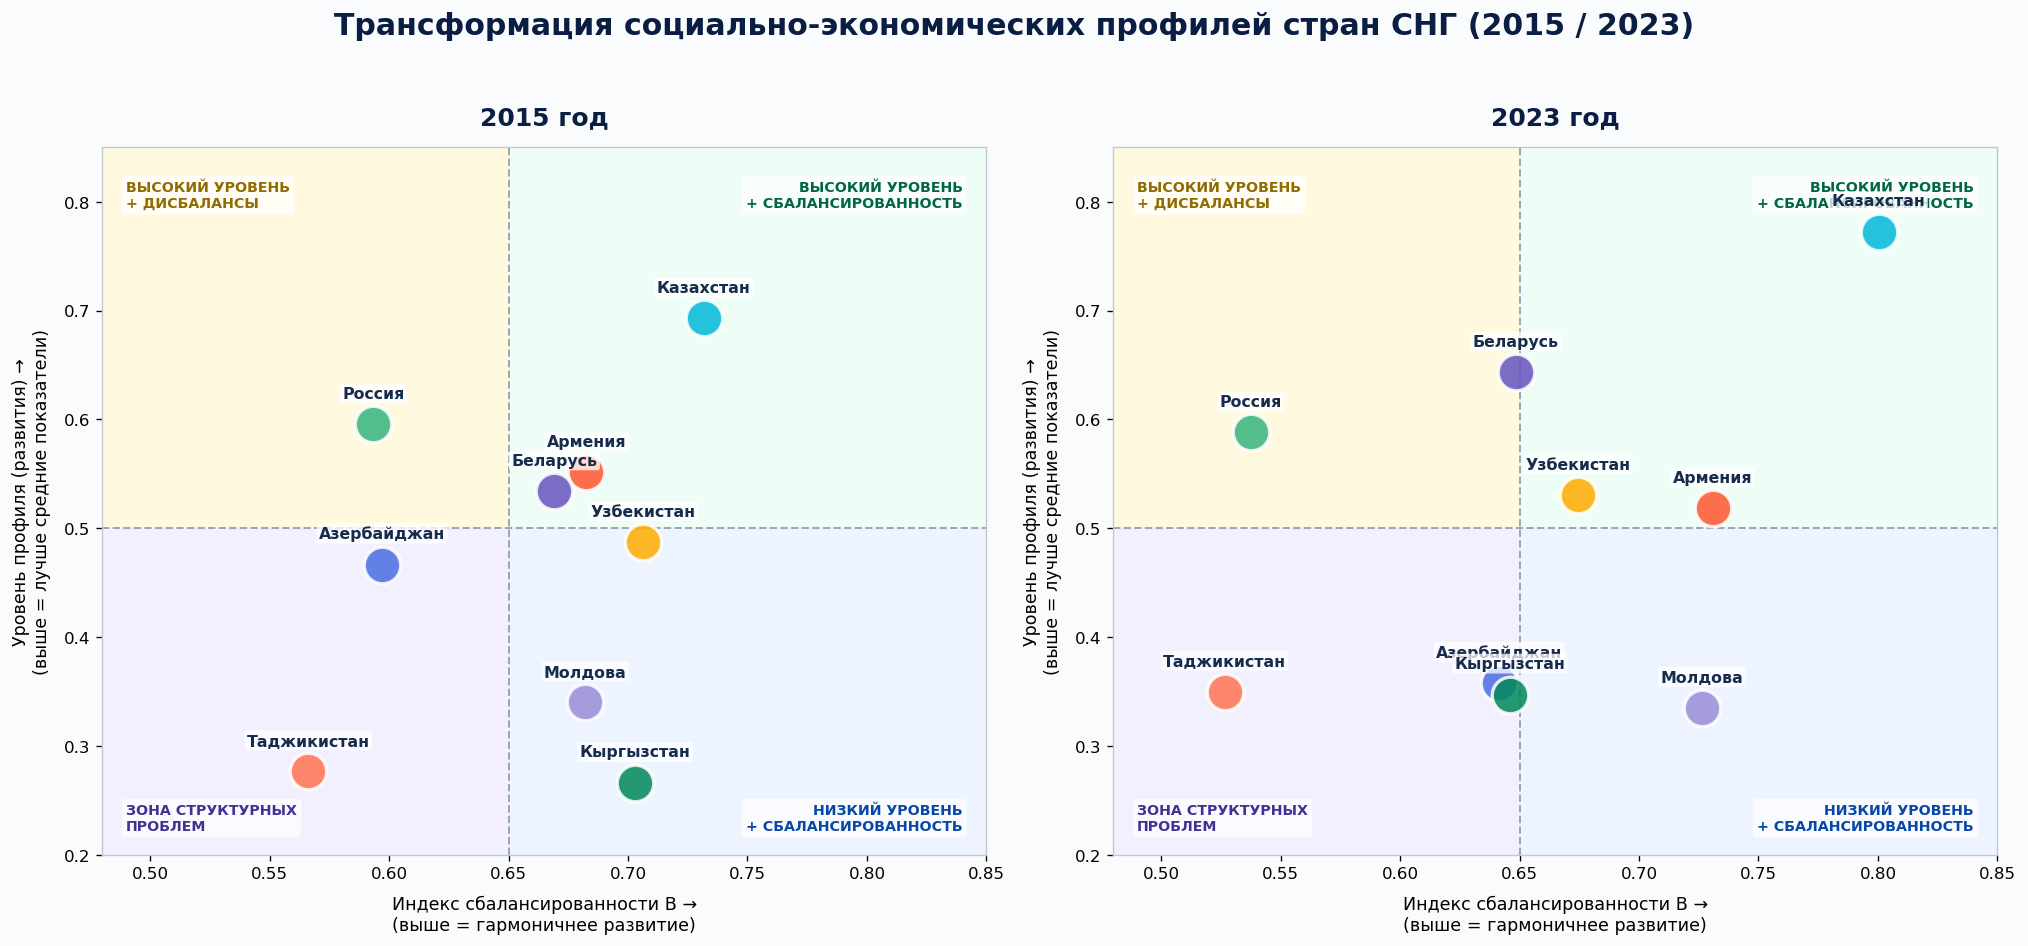

In [14]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_2015 = pd.read_csv("кв_2015.csv", sep=";", decimal=",", encoding="utf-8-sig")
df_2023 = pd.read_csv("кв_2023.csv", sep=";", decimal=",", encoding="utf-8-sig")


X_SPLIT = 0.65  
Y_SPLIT = 0.50  

country_palette = {
    "Россия": "#36B37E",
    "Казахстан": "#00B8D9",
    "Беларусь": "#6554C0",
    "Армения": "#FF5630",
    "Узбекистан": "#FFAB00",
    "Азербайджан": "#4A6EE0",
    "Молдова": "#998DD9",
    "Кыргызстан": "#00875A",
    "Таджикистан": "#FF7452",
}


def plot_quadrant_map(ax, df, year_title):

    x_min, x_max = 0.48, 0.85
    y_min, y_max = 0.20, 0.85

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.add_patch(
        patches.Rectangle(
            (X_SPLIT, Y_SPLIT),
            x_max - X_SPLIT,
            y_max - Y_SPLIT,
            facecolor="#E3FCEF",
            alpha=0.6,
            zorder=0,
        )
    )

    ax.add_patch(
        patches.Rectangle(
            (x_min, Y_SPLIT),
            X_SPLIT - x_min,
            y_max - Y_SPLIT,
            facecolor="#FFF0B3",
            alpha=0.4,
            zorder=0,
        )
    )

    ax.add_patch(
        patches.Rectangle(
            (X_SPLIT, y_min),
            x_max - X_SPLIT,
            Y_SPLIT - y_min,
            facecolor="#DEEBFF",
            alpha=0.5,
            zorder=0,
        )
    )

    ax.add_patch(
        patches.Rectangle(
            (x_min, y_min),
            X_SPLIT - x_min,
            Y_SPLIT - y_min,
            facecolor="#EAE6FF",
            alpha=0.6,
            zorder=0,
        )
    )

    ax.axvline(
        X_SPLIT,
        color="#7A869A",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        zorder=1,
    )
    ax.axhline(
        Y_SPLIT,
        color="#7A869A",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        zorder=1,
    )

    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
    ax.text(
        x_min + 0.01,
        y_max - 0.03,
        "ВЫСОКИЙ УРОВЕНЬ\n+ ДИСБАЛАНСЫ",
        fontsize=8.5,
        fontweight="bold",
        color="#8F6B00",
        va="top",
        bbox=bbox_props,
    )
    ax.text(
        x_max - 0.01,
        y_max - 0.03,
        "ВЫСОКИЙ УРОВЕНЬ\n+ СБАЛАНСИРОВАННОСТЬ",
        fontsize=8.5,
        fontweight="bold",
        color="#006644",
        ha="right",
        va="top",
        bbox=bbox_props,
    )
    ax.text(
        x_min + 0.01,
        y_min + 0.02,
        "ЗОНА СТРУКТУРНЫХ\nПРОБЛЕМ",
        fontsize=8.5,
        fontweight="bold",
        color="#403294",
        va="bottom",
        bbox=bbox_props,
    )
    ax.text(
        x_max - 0.01,
        y_min + 0.02,
        "НИЗКИЙ УРОВЕНЬ\n+ СБАЛАНСИРОВАННОСТЬ",
        fontsize=8.5,
        fontweight="bold",
        color="#0747A6",
        ha="right",
        va="bottom",
        bbox=bbox_props,
    )

    for _, row in df.iterrows():
        country = row["Страна"]
        x = row["Индекс сбалансированности B"]
        y = row["Уровень профиля"]
        c_color = country_palette.get(country, "#344563")

        ax.scatter(
            x,
            y,
            s=480,
            color=c_color,
            alpha=0.85,
            edgecolors="white",
            linewidth=2,
            zorder=3,
        )

        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color="#172B4D",
            zorder=4,
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )


    ax.set_title(year_title, fontsize=15, weight="bold", pad=14, color="#091E42")
    ax.set_xlabel(
        "Индекс сбалансированности B →\n(выше = гармоничнее развитие)",
        fontsize=10.5,
        labelpad=8,
    )
    ax.set_ylabel(
        "Уровень профиля (развития) →\n(выше = лучше средние показатели)",
        fontsize=10.5,
        labelpad=8,
    )
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_edgecolor("#C1C7D0")
        spine.set_linewidth(0.8)


fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(17, 8), facecolor="#FAFBFC", dpi=120
)

plot_quadrant_map(ax1, df_2015, "2015 год")
plot_quadrant_map(ax2, df_2023, "2023 год")

plt.suptitle(
    "Трансформация социально-экономических профилей стран СНГ (2015 / 2023)",
    fontsize=18,
    weight="bold",
    color="#091E42",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

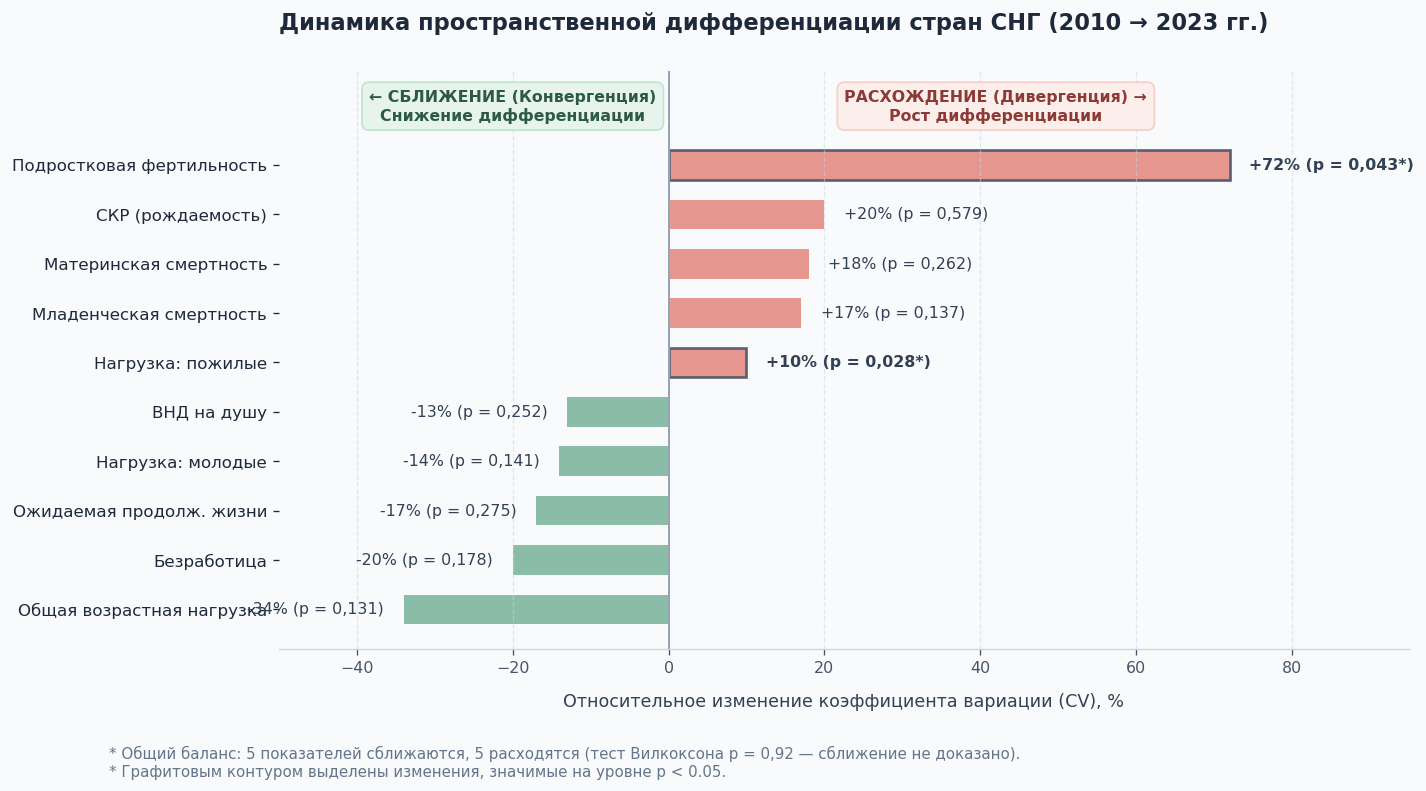

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = {
    "Показатель": [
        "Подростковая фертильность",
        "СКР (рождаемость)",
        "Материнская смертность",
        "Младенческая смертность",
        "Нагрузка: пожилые",
        "ВНД на душу",
        "Нагрузка: молодые",
        "Ожидаемая продолж. жизни",
        "Безработица",
        "Общая возрастная нагрузка",
    ],
    "Изменение": [72, 20, 18, 17, 10, -13, -14, -17, -20, -34],
    "p_val": [
        "0,043*",
        "0,579",
        "0,262",
        "0,137",
        "0,028*",
        "0,252",
        "0,141",
        "0,275",
        "0,178",
        "0,131",
    ],
    "sig": [True, False, False, False, True, False, False, False, False, False],
}

df = pd.DataFrame(data)
df = df.sort_values(by="Изменение", ascending=True).reset_index(drop=True)

plt.figure(figsize=(12, 7.2), dpi=120, facecolor="#F8FAFC")
ax = plt.subplot(111)
ax.set_facecolor("#F8FAFC")


colors = ["#7FB69E" if val < 0 else "#E68B83" for val in df["Изменение"]]

bars = ax.barh(
    df["Показатель"],
    df["Изменение"],
    color=colors,
    height=0.6,
    alpha=0.9,
    edgecolor="none",
)

for i, bar in enumerate(bars):
    if df.loc[i, "sig"]:
        bar.set_edgecolor("#475569")
        bar.set_linewidth(1.6)

ax.axvline(0, color="#94A3B8", linewidth=1.2, linestyle="-")

for i, (val, p, sig) in enumerate(zip(df["Изменение"], df["p_val"], df["sig"])):
    offset = 2.5 if val > 0 else -2.5
    ha = "left" if val > 0 else "right"
    sign = "+" if val > 0 else ""
    weight = "bold" if sig else "normal"

    label = f"{sign}{val}% (p = {p})"
    ax.text(
        val + offset,
        i,
        label,
        va="center",
        ha=ha,
        fontsize=9.5,
        color="#334155",
        weight=weight,
    )

ax.text(
    -20,
    9.85,
    "← СБЛИЖЕНИЕ (Конвергенция)\nСнижение дифференциации",
    ha="center",
    va="bottom",
    fontsize=9.5,
    fontweight="bold",
    color="#2D5A43",
    bbox=dict(
        boxstyle="round,pad=0.45", fc="#E7F4ED", ec="#BFE3D0", linewidth=1
    ),
)

ax.text(
    42,
    9.85,
    "РАСХОЖДЕНИЕ (Дивергенция) →\nРост дифференциации",
    ha="center",
    va="bottom",
    fontsize=9.5,
    fontweight="bold",
    color="#8C3A35",
    bbox=dict(
        boxstyle="round,pad=0.45", fc="#FCEEEB", ec="#F6CEC6", linewidth=1
    ),
)


ax.set_xlim(-50, 95)
ax.set_ylim(-0.8, 10.9)

ax.set_xlabel(
    "Относительное изменение коэффициента вариации (CV), %",
    fontsize=10.5,
    labelpad=10,
    color="#334155",
    fontweight="500",
)
ax.tick_params(axis="y", labelsize=10, colors="#1E293B")
ax.tick_params(axis="x", labelsize=9.5, colors="#475569")

plt.title(
    "Динамика пространственной дифференциации стран СНГ (2010 → 2023 гг.)",
    fontsize=13.5,
    fontweight="bold",
    pad=25,
    color="#1E293B",
    loc="left",
)
plt.suptitle(
    "* Общий баланс: 5 показателей сближаются, 5 расходятся (тест Вилкоксона p = 0,92 — сближение не доказано).\n* Графитовым контуром выделены изменения, значимые на уровне p < 0.05.",
    fontsize=9,
    color="#64748B",
    x=0.08,
    y=0.02,
    ha="left",
)


ax.grid(axis="x", linestyle="--", alpha=0.5, color="#CBD5E1")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

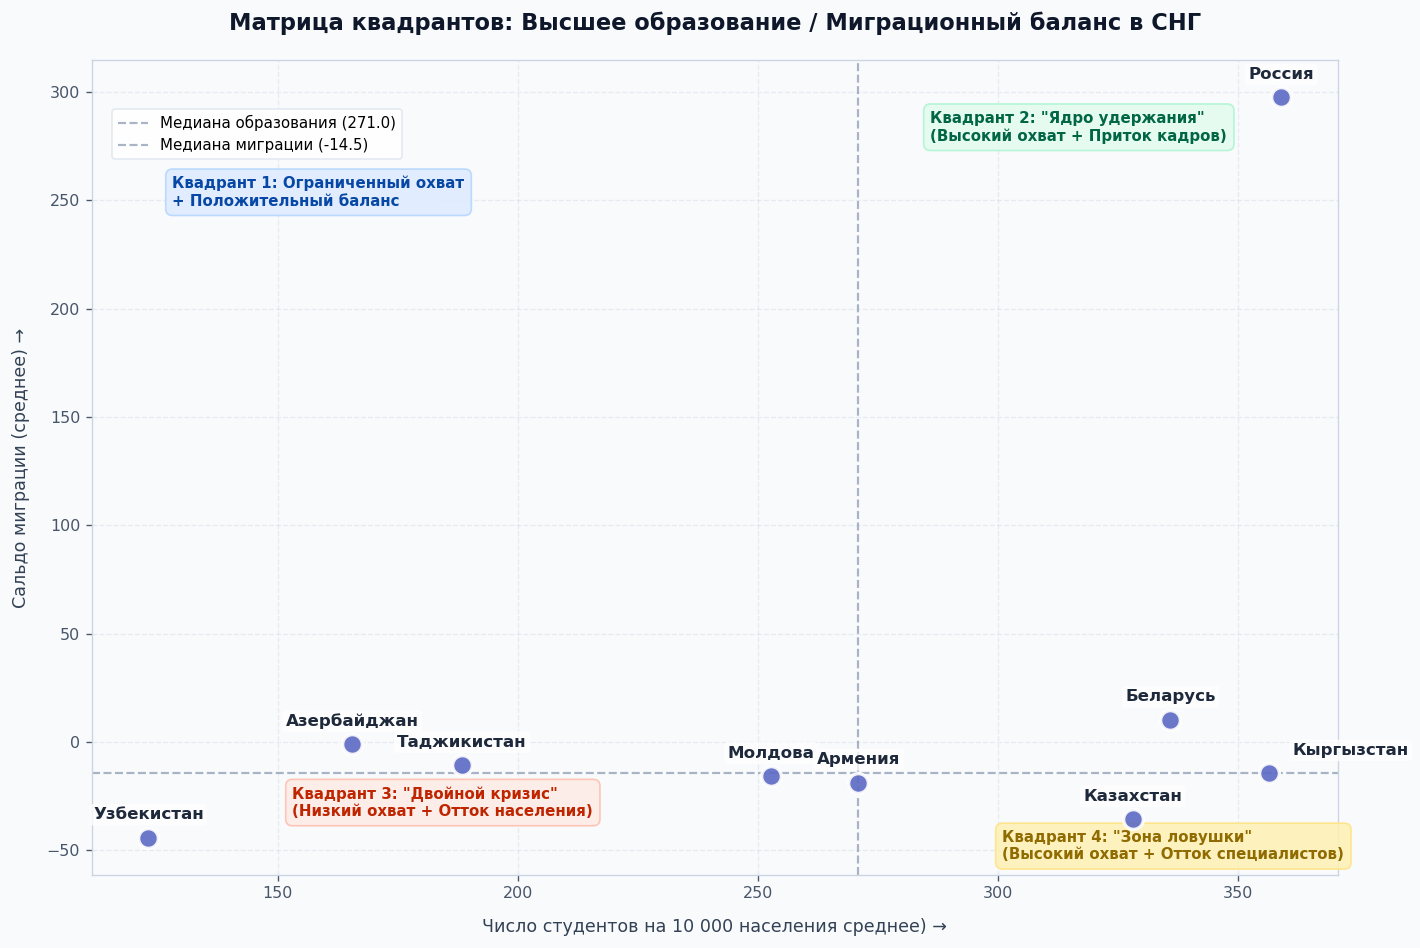

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

file_name = 'Гипотеза_3.xlsx'
excel_file = pd.ExcelFile(file_name)
sheet_name = 'Анализ' if 'Анализ' in excel_file.sheet_names else 'анализ'
df = pd.read_excel(file_name, sheet_name=sheet_name)

df_country = (
    df.groupby('country')[['high_educ', 'migration']].mean().reset_index()
)

x_median = df_country['high_educ'].median()
y_median = df_country['migration'].median()

x_min, x_max = df_country['high_educ'].min(), df_country['high_educ'].max()
y_min, y_max = df_country['migration'].min(), df_country['migration'].max()


fig, ax = plt.subplots(figsize=(12, 8), dpi=120, facecolor='#F8FAFC')
ax.set_facecolor('#F8FAFC')


ax.scatter(
    df_country['high_educ'],
    df_country['migration'],
    color='#5C6AC4',  
    s=140,
    zorder=4,
    edgecolors='white',
    linewidth=2,
    alpha=0.9,
)

for i, row in df_country.iterrows():
  ha_align = 'left' if row['country'] == 'Кыргызстан' else 'center'
  x_offset = 14 if row['country'] == 'Кыргызстан' else 0

  ax.annotate(
      row['country'],
      (row['high_educ'], row['migration']),
      textcoords='offset points',
      xytext=(x_offset, 11),
      ha=ha_align,
      fontsize=10,
      weight='bold',
      color='#1E293B',  
      zorder=5,
      bbox=dict(
          boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75
      ),
  )

ax.axvline(
    x_median,
    color='#94A3B8',
    linestyle='--',
    linewidth=1.3,
    alpha=0.8,
    zorder=2,
    label=f'Медиана образования ({x_median:.1f})',
)
ax.axhline(
    y_median,
    color='#94A3B8',
    linestyle='--',
    linewidth=1.3,
    alpha=0.8,
    zorder=2,
    label=f'Медиана миграции ({y_median:.1f})',
)

ax.text(
    x_min + 5,
    y_max - 50,
    'Квадрант 1: Ограниченный охват\n+ Положительный баланс',
    fontsize=9,
    weight='bold',
    color='#0747A6',
    bbox=dict(
        boxstyle='round,pad=0.45', fc='#DEEBFF', ec='#B3D4FF', alpha=0.85
    ),
)

ax.text(
    x_median + 15,
    y_max - 20,
    'Квадрант 2: "Ядро удержания"\n(Высокий охват + Приток кадров)',
    fontsize=9,
    weight='bold',
    color='#006644',
    bbox=dict(
        boxstyle='round,pad=0.45', fc='#E3FCEF', ec='#ABF5D1', alpha=0.85
    ),
)

ax.text(
    x_min + 30,
    y_min + 10,
    'Квадрант 3: "Двойной кризис"\n(Низкий охват + Отток населения)',
    fontsize=9,
    weight='bold',
    color='#BF2600',
    bbox=dict(
        boxstyle='round,pad=0.45', fc='#FFEBE6', ec='#FFBDAD', alpha=0.85
    ),
)

ax.text(
    x_median + 30,
    y_min - 10,
    'Квадрант 4: "Зона ловушки"\n(Высокий охват + Отток специалистов)',
    fontsize=9,
    weight='bold',
    color='#8F6B00',
    bbox=dict(
        boxstyle='round,pad=0.45', fc='#FFF0B3', ec='#FFE380', alpha=0.85
    ),
)

ax.set_title(
    'Матрица квадрантов: Высшее образование / Миграционный баланс в СНГ',
    fontsize=13.5,
    weight='bold',
    pad=18,
    color='#0F172A',
)
ax.set_xlabel(
    'Число студентов на 10 000 населения среднее) →',
    fontsize=10.5,
    labelpad=10,
    color='#334155',
)
ax.set_ylabel(
    'Сальдо миграции (среднее) →',
    fontsize=10.5,
    labelpad=10,
    color='#334155',
)

ax.tick_params(colors='#475569', labelsize=9.5)
ax.grid(True, linestyle='--', alpha=0.4, color='#CBD5E1')

for spine in ax.spines.values():
  spine.set_edgecolor('#CBD5E1')

ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.01, 0.95),
    framealpha=0.9,
    edgecolor='#E2E8F0',
    fontsize=9,
)
plt.tight_layout()
plt.show()